In [ ]:
import scipy
import pandas as pd
import numpy as np
import re
import warnings

warnings.filterwarnings('ignore')

lr_kallisto_files=['LRGASP_data/LRGASP_data/human_WTC11_ONT_cDNA_k-63_bus_lr_quant_tcc.tsv',
        'LRGASP_data/LRGASP_data/human_WTC11_ONT_dRNA_k-63_bus_lr_quant_tcc.tsv', 
        'LRGASP_data/LRGASP_data/human_WTC11_PacBio_cDNA_k-63_bus_lr_quant_tcc.tsv',
        'LRGASP_data/LRGASP_data/human_WTC11_ONT_CapTrap_k-63_bus_lr_quant_tcc.tsv', 
        'LRGASP_data/LRGASP_data/human_WTC11_PacBio_CapTrap_k-63_bus_lr_quant_tcc.tsv'] 

oarfish_files=['LRGASP_data/LRGASP_data/oarfish_quants_v0.5.1/human_WTC11_ONT_cDNA_oarfish.tsv',
               'LRGASP_data/LRGASP_data/oarfish_quants_v0.5.1/human_WTC11_ONT_dRNA_oarfish.tsv',
               'LRGASP_data/LRGASP_data/oarfish_quants_v0.5.1/human_WTC11_PacBio_cDNA_oarfish.tsv',
               'LRGASP_data/LRGASP_data/oarfish_quants_v0.5.1/human_WTC11_ONT_CapTrap_oarfish.tsv',
               'LRGASP_data/LRGASP_data/oarfish_quants_v0.5.1/human_WTC11_PacBio_CapTrap_oarfish.tsv']

true_datas=['Challenge2_Figures_Data/SIRV-set4_data/raw_data/IsoQuant_WTC11_cDNA_ONT.tsv',
            'Challenge2_Figures_Data/SIRV-set4_data/raw_data/IsoQuant_WTC11_dRNA_ONT.tsv',
            'Challenge2_Figures_Data/SIRV-set4_data/raw_data/IsoQuant_WTC11_cDNA_PacBio.tsv',
            'Challenge2_Figures_Data/SIRV-set4_data/raw_data/IsoQuant_WTC11_CapTrap_ONT.tsv',
            'Challenge2_Figures_Data/SIRV-set4_data/raw_data/IsoQuant_WTC11_CapTrap_PacBio.tsv']

def calculate_PET(input_file, truth, set_exp):
    # Initialize variables to store the sum and count
    total_sirvs = 0
    count_expressed = 0
    
    # Open the CSV file for reading
    with open(input_file, newline='') as csvfile:
        data = pd.read_csv(csvfile, sep='\t', header=0, names = ['transcript_id', 'bcounts1', 'bcounts2', 'bcounts3'])
        # Calculate the mean of the 2nd, 3rd, and 4th columns (index 1, 2, 3) for each row
        #data['bcounts1']=data['bcounts1']/data['bcounts1'].sum()*1000000
        #data['bcounts2']=data['bcounts2']/data['bcounts2'].sum()*1000000
        #data['bcounts3']=data['bcounts3']/data['bcounts3'].sum()*1000000
        data['average_exp'] = data.iloc[:, 1:4].mean(axis=1)
        count = data.merge(truth, how="outer", on="transcript_id")
    
        # Create a new DataFrame with the first column and the new average column
        mean_exp = data[['transcript_id', 'average_exp']]  # Assuming the first column is 'id'
        
        for gene, row in count.iterrows():
            # Ensure that there are enough columns (at least 4)
            if len(row) >= 4 and re.match(set_exp, row[0]):
                #print(row)
                # Extract the 2nd through 4th columns (index 1 to 3)
                col2 = float(row[1])
                col3 = float(row[2])
                col4 = float(row[3])
                if (col2 > .0000001) or (col3 > 0.0000001) or (col4 > .0000001):
                    count_expressed+=1  # We are counting 3 columns
                    total_sirvs+=1
                else:
                    total_sirvs+=1
                
    PET=count_expressed/total_sirvs
    print(set_exp+" PET = ", PET)
    return PET, mean_exp

def compute_MRD(true, est):
    # Compute the absolute differences between corresponding values
    abs_diff = abs(true - est)

    
    # Compute the relative difference (absolute difference divided by the truth)
    rel_diff = abs_diff / true
    
    # Compute the median of the relative differences
    mrd = rel_diff.median()
    
    return mrd

def calculate_nrmse(y_pred, y_true):
    """
    Calculate the Normalized Root Mean Squared Error (NRMSE)
    
    Parameters:
    y_true (pandas Series or numpy array): True values
    y_pred (pandas Series or numpy array): Predicted values
    
    Returns:
    float: The NRMSE value
    """
    # Calculate the Root Mean Squared Error (RMSE)
    rmse = np.sqrt(((y_true - y_pred) ** 2).mean())
    
    # Calculate the range of true values
    sample_std = np.std(y_true, ddof=1) 
    
    # Normalize RMSE by the range of true values
    print('num of transcripts', len(y_true))
    nrmse = rmse / sample_std
    
    return nrmse
    
def calculate_MRD_SCC_NRMSE(input_mean, truth, set_exp):
    count = truth.merge(input_mean, how="outer", on="transcript_id")
    # Filter rows where the 'transcript_id' column contains 'SIRV'
    subset_count = count[count['transcript_id'].str.contains(set_exp, na=False)]
    subset_count = subset_count.fillna(0)
    
    x = subset_count["truth_normalized"]*1000000
    y = subset_count["average_exp"]/subset_count["average_exp"].sum()*1000000 #normalize after averaging 
    mrd = compute_MRD(x,y)
    rho = scipy.stats.spearmanr(x,y).correlation   # Spearman's rho

    nrmse = calculate_nrmse(x,y)
    print("MRD:\t", mrd)
    print("Spearman's rho:\t", rho)
    print("NRMSE:\t", nrmse)

    return mrd, rho, nrmse

# Example usage
def compute_metrics(files, tool):
    mean_ercc_pet = []
    mean_sirv_pet = []
    mean_sirv_long_pet = []
    mrd_mean = []
    scc_mean = []
    nrmse_mean = []
    for f, file in enumerate(files):
        file_s = file.split('_')
        print(file_s[3]+'\t'+file_s[4]+'\t'+file_s[5])
        true_data = pd.read_csv(true_datas[f], sep='\t', header=0, names=['transcript_id', 'est', 'truth', 'est_normalized', 'truth_normalized'])
        PET_value_sirv, mean_data = calculate_PET(file, true_data, r'^SIRV\d{3}$')
        mean_sirv_pet.append(PET_value_sirv)
        PET_value_long, mean_data = calculate_PET(file, true_data, r'SIRV400\d{1}|SIRV600\d{1}|SIRV800\d{1}|SIRV100\d{2}|SIRV120\d{2}')
        mean_sirv_long_pet.append(PET_value_long)
        PET_value_ERCC, throw_data = calculate_PET(file, true_data, r'DQ|EF')
        mean_ercc_pet.append(PET_value_ERCC)
    
        #Tools	Samples	Protocols	Platforms	Protocols_Platforms	MRD	SCC	NRMSE
        #for all "SIRV|EF|DQ"
        mrd, scc, nrmse = calculate_MRD_SCC_NRMSE(mean_data, true_data, 'SIRV|EF') #"SIRV|EF")
        mrd_mean.append(mrd)
        scc_mean.append(scc)
        nrmse_mean.append(nrmse)
    
        print(tool+"\t"+file_s[3]+'\t'+file_s[5]+'\t'+file_s[4]+'\t'+file_s[5]+'_'+file_s[4]+'\t'+str(mrd)+'\t'+str(scc)+'\t'+str(nrmse))
        print(tool+"\t"+file_s[3]+'\t'+file_s[5]+'\t'+file_s[4]+'\t'+file_s[5]+'_'+file_s[4]+'\t'+str(PET_value_sirv)+'\t'+str(PET_value_long)+'\t'+str(PET_value_ERCC))

    print("Mean PET SIRV: ", np.array(mean_sirv_pet).mean())
    print("Mean PET long SIRV: ", np.array(mean_sirv_long_pet).mean())
    print("Mean PET ERCC: ", np.array(mean_ercc_pet).mean())
    
    print("Mean SCC: ", np.array(scc_mean).mean())
    print("Mean MRD: ", np.array(mrd_mean).mean())
    print("Mean NRMSE: ", np.array(nrmse_mean).mean())

compute_metrics(lr_kallisto_files, "lr-kallisto")
compute_metrics(oarfish_files, "oarfish")



''' format as 
Tools	Samples	Protocols	Platforms	Protocols_Platforms	MRD	SCC	NRMSE
IsoQuant	WTC11	CapTrap	ONT	CapTrap_ONT	0.117516	0.707157	0.875999
IsoQuant	WTC11	CapTrap	PacBio	CapTrap_PacBio	0.089567	0.687596	0.966741
IsoQuant	WTC11	cDNA	ONT	cDNA_ONT	0.19441	0.819983	0.726124
IsoQuant	WTC11	cDNA	PacBio	cDNA_PacBio	0.112298	0.824536	0.577564
IsoQuant	WTC11	dRNA	ONT	dRNA_ONT	0.150506	0.774741	1.141167
IsoQuant	WTC11	R2C2	ONT	R2C2_ONT	0.096776	0.763177	0.729086
Bambu	WTC11	CapTrap	ONT	CapTrap_ONT	0.742321	0.694437	1.530848
Bambu	WTC11	CapTrap	PacBio	CapTrap_PacBio	0.696897	0.698079	1.50108
Bambu	WTC11	cDNA	ONT	cDNA_ONT	0.712257	0.769848	1.435557
Bambu	WTC11	cDNA	PacBio	cDNA_PacBio	0.599066	0.694115	1.422977
Bambu	WTC11	dRNA	ONT	dRNA_ONT	1	0.545833	1.786669
Bambu	WTC11	R2C2	ONT	R2C2_ONT	1	0.618413	1.665321
Bambu	WTC11	CapTrap	ONT	CapTrap_ONT	0.650821	0.81865	1.280367
Bambu	WTC11	CapTrap	PacBio	CapTrap_PacBio	0.681199	0.717049	1.452405
Bambu	WTC11	cDNA	ONT	cDNA_ONT	0.637964	0.805014	1.345438
Bambu	WTC11	cDNA	PacBio	cDNA_PacBio	0.557491	0.713237	1.367503
Bambu	WTC11	dRNA	ONT	dRNA_ONT	1	0.575749	1.713199
Bambu	WTC11	R2C2	ONT	R2C2_ONT	0.660704	0.717501	1.476841
lr-kallisto	WTC11	cDNA	ONT	cDNA_ONT	0.888363	0.853871	1.70248
lr-kallisto	WTC11	dRNA	ONT	dRNA_ONT	1.0	0.834938	1.70163
lr-kallisto	WTC11	cDNA	PacBio	cDNA_PacBio	0.658970	0.827338	0.496551
lr-kallisto	WTC11	CapTrap	ONT	CapTrap_ONT	0.653229	0.822992	0.772111
lr-kallisto	WTC11	CapTrap	PacBio	CapTrap_PacBio	0.684568	0.820710	0.634639
oarfish	WTC11	cDNA	ONT	cDNA_ONT	0.9058405942373381	0.8627881834021652	1.6577814942172249
oarfish	WTC11	dRNA	ONT	dRNA_ONT	1.0	0.8297702481841924	1.8939048798986566
oarfish	WTC11	cDNA	PacBio	cDNA_PacBio	0.6578071732318092	0.8406627182377618	0.4851091944436655
oarfish	WTC11	CapTrap	ONT	CapTrap_ONT	0.6682278098425039	0.8168356441433112	0.7737167662679654
oarfish	WTC11	CapTrap	PacBio	CapTrap_PacBio	0.6152220374950734	0.8278602064159856	0.6326921656548591
Oarfish:
Mean PET SIRV:  98.78321678321679
Mean PET long SIRV:  93.33333333333334
Mean PET ERCC:  69.1184265455154
Mean SCC:  0.8355834000766833
Mean MRD:  0.769419522961345
Mean NRMSE:  1.0886409000964743
lr-kallisto: 
Mean PET SIRV:  92.7536231884058
Mean PET long SIRV:  93.33333333333334
Mean PET ERCC:  45.0
Mean SCC:  0.8319696857013341
Mean MRD:  0.7770256450304208
Mean NRMSE:  1.061482546504602
'''
'''
oarfish	WTC11	cDNA	ONT	cDNA_ONT	0.9023721910037756	0.8677800442965254	1.6889884632575203
oarfish	WTC11	dRNA	ONT	dRNA_ONT	1.0	0.8300993128873794	1.9081730179092484
oarfish	WTC11	cDNA	PacBio	cDNA_PacBio	0.6634740729479305	0.8325141109819628	0.4844687271498416
oarfish	WTC11	CapTrap	ONT	CapTrap_ONT	0.6729252632622675	0.8210160969812194	0.7737219020035493
oarfish	WTC11	CapTrap	PacBio	CapTrap_PacBio	0.610514975099305	0.8411444392393923	0.632253305227404
'''

WTC11	ONT	cDNA
^SIRV\d{3}$ PET =  0.9565217391304348


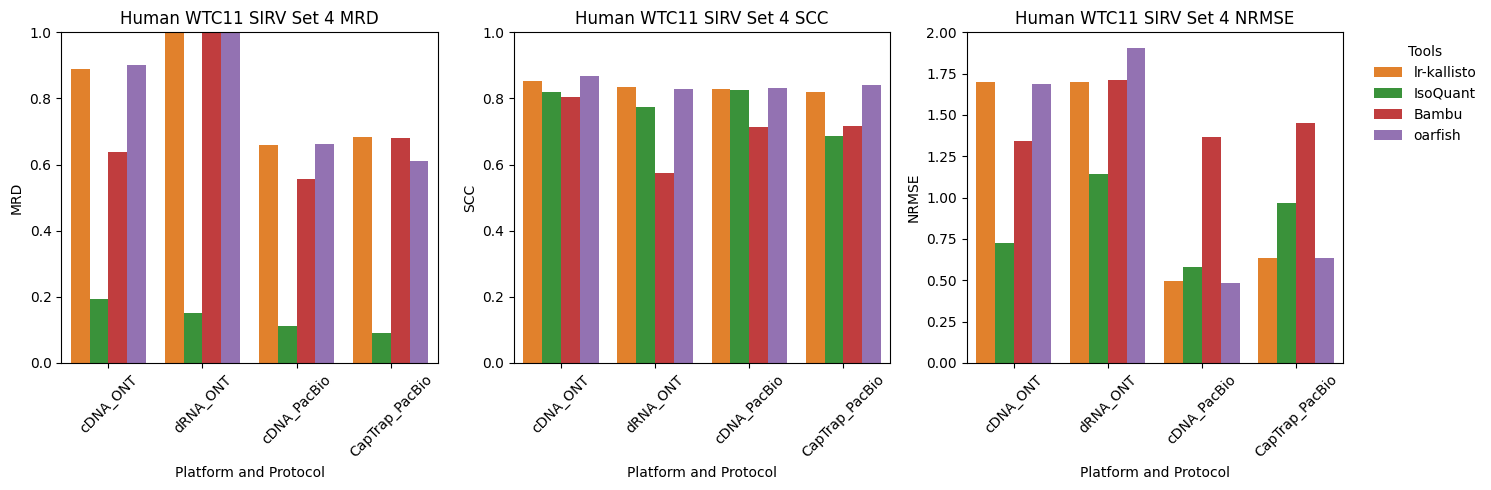

In [226]:
#!pip install pandas seaborn matplotlib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Function to generate box and whisker plots
def generate_boxplots(input_file):
    # Read the TSV file into a pandas DataFrame
    df = pd.read_csv(input_file, sep='\t')

    # Set up the matplotlib figure
    plt.figure(figsize=(15, 5))

    # Generate separate boxplots for MRD, SCC, and NRMSE
    columns_to_plot = ['MRD', 'SCC', 'NRMSE']
    for i, col in enumerate(columns_to_plot):
        plt.subplot(1, 3, i+1)  # Create 1 row and 3 columns of plots
        
        # Create a boxplot with 'Tools' on x-axis and 'Protocols_Platforms' for coloring
        sns.barplot(x='Protocols_Platforms', y=col, data=df, hue='Tools', palette=['C1', 'C2', 'C3', 'C4'])#palette="Set1")

        # Set plot title and labels
        plt.title(f'Human WTC11 SIRV Set 4 {col}')
        plt.xlabel('Platform and Protocol')
        plt.ylabel(col)
        plt.ylim(0, round(np.max(df[col])))
        plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
        plt.legend([], [], frameon=False)

    plt.legend(title='Tools', loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

    # Adjust layout to make sure labels fit
    plt.tight_layout()

    # Show the plot
    plt.show()

# Example usage
input_file = 'Challenge2_Figures_Data/SIRV-set4_data/lr_kallisto_metrics.txt'  # Replace with the path to your TSV file
generate_boxplots(input_file)


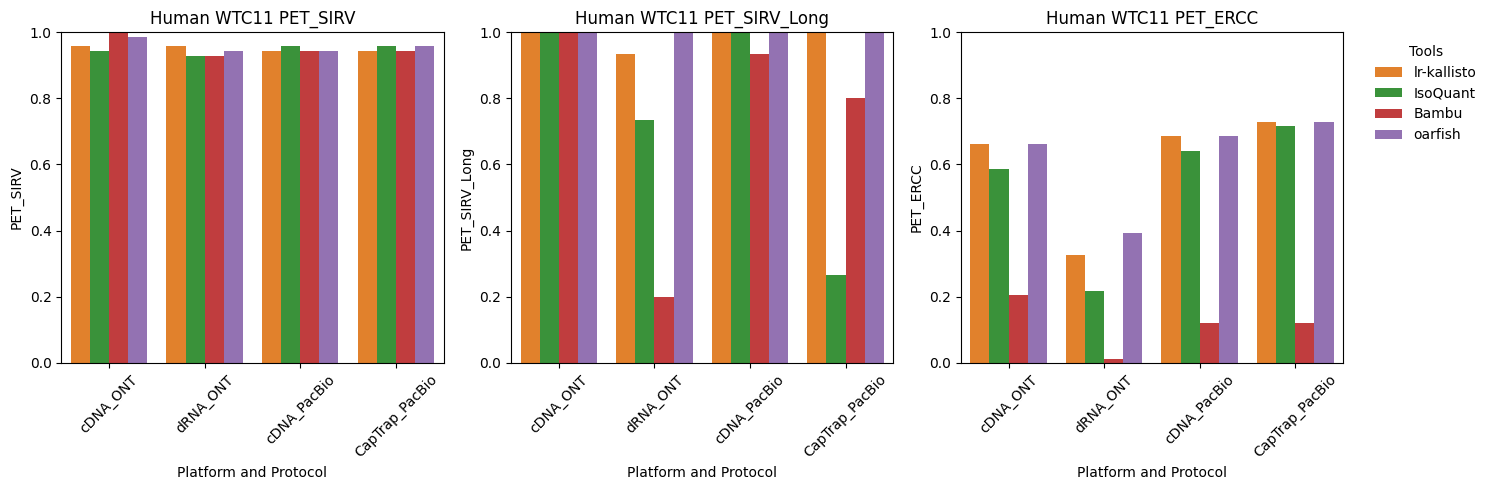

In [225]:
#!pip install pandas seaborn matplotlib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Function to generate box and whisker plots
def generate_boxplots(input_file):
    # Read the TSV file into a pandas DataFrame
    df = pd.read_csv(input_file, sep='\t')

    # Set up the matplotlib figure
    plt.figure(figsize=(15, 5))

    # Generate separate boxplots for MRD, SCC, and NRMSE
    columns_to_plot = ['PET_SIRV', 'PET_SIRV_Long', 'PET_ERCC']
    for i, col in enumerate(columns_to_plot):
        plt.subplot(1, 3, i+1)  # Create 1 row and 3 columns of plots
        
        # Create a boxplot with 'Tools' on x-axis and 'Protocols_Platforms' for coloring
        sns.barplot(x='Protocols_Platforms', y=col, data=df, hue='Tools', palette=['C1', 'C2', 'C3', 'C4'])#palette="Set1")

        # Set plot title and labels
        plt.title(f'Human WTC11 {col}')
        plt.xlabel('Platform and Protocol')
        plt.ylabel(col)
        plt.ylim(0, round(np.max(df[col])))
        plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
        plt.legend([], [], frameon=False)

    plt.legend(title='Tools', loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

    # Adjust layout to make sure labels fit
    plt.tight_layout()

    # Show the plot
    plt.show()

# Example usage
input_file = 'Challenge2_Figures_Data/SIRV-set4_data/lr_kallisto_PET_metrics.txt'  # Replace with the path to your TSV file
generate_boxplots(input_file)


In [193]:
'''
Tools	Samples	Protocols	Platforms	Protocols_Platforms	PET_SIRV PET_SIRV_Long PET_ERCC
IsoQuant	WTC11	CapTrap	ONT	CapTrap_ONT	0.956522 0.6 0.793478
IsoQuant	WTC11	CapTrap	PacBio	CapTrap_PacBio	0.956522 0.266667 0.717391
IsoQuant	WTC11	cDNA	ONT	cDNA_ONT	0.942029 1 0.586957
IsoQuant	WTC11	cDNA	PacBio	cDNA_PacBio	0.956522 1 0.641304
IsoQuant	WTC11	dRNA	ONT	dRNA_ONT	0.927536 0.733333 0.217391
Bambu	WTC11	CapTrap	ONT	CapTrap_ONT	0.782609 0.93333 0.326087
Bambu	WTC11	CapTrap	PacBio	CapTrap_PacBio	0.898551 0.8 0.119565
Bambu	WTC11	cDNA	ONT	cDNA_ONT	0.927536 1.0 0.206522
Bambu	WTC11	cDNA	PacBio	cDNA_PacBio	0.898551 .93333 0.119565
Bambu	WTC11	dRNA	ONT	dRNA_ONT	0.855072 0.2 0.01087
Bambu	WTC11	CapTrap	ONT	CapTrap_ONT	1 0.93333 0.326087
Bambu	WTC11	CapTrap	PacBio	CapTrap_PacBio	0.942029 0.8 0.119565
Bambu	WTC11	cDNA	ONT	cDNA_ONT	1 1 0.206522
Bambu	WTC11	cDNA	PacBio	cDNA_PacBio	0.942029 0.93333 0.119565
Bambu	WTC11	dRNA	ONT	dRNA_ONT	0.927536 0.2 0.01087
lr-kallisto	WTC11	cDNA	ONT	cDNA_ONT	.9565217391304348	1.000	.6630434782608695
lr-kallisto	WTC11	dRNA	ONT	dRNA_ONT	.9565217391304348	.9333333333333333	.32608695652173914
lr-kallisto	WTC11	cDNA	PacBio	cDNA_PacBio	.9420289855072464	1.000	.6847826086956522
lr-kallisto	WTC11	CapTrap	ONT	CapTrap_ONT	.9565217391304348	1.000	.8804347826086956
lr-kallisto	WTC11	CapTrap	PacBio	CapTrap_PacBio	.9420289855072464	1.000	.7282608695652173
oarfish	WTC11	cDNA	ONT	cDNA_ONT	0.9855072463768116	1.0	0.6630434782608695
oarfish	WTC11	dRNA	ONT	dRNA_ONT	0.9420289855072463	1.0	0.391304347826087
oarfish	WTC11	cDNA	PacBio	cDNA_PacBio	0.9420289855072463	1.0	0.6847826086956522
oarfish	WTC11	CapTrap	ONT	CapTrap_ONT	0.9565217391304348	1.0	0.8913043478260869
oarfish	WTC11	CapTrap	PacBio	CapTrap_PacBio	0.9565217391304348	1.0	0.7282608695652174
'''

'\nTools\tSamples\tProtocols\tPlatforms\tProtocols_Platforms\tPET_SIRV PET_SIRV_Long PET_ERCC\nIsoQuant\tWTC11\tCapTrap\tONT\tCapTrap_ONT\t0.956522 0.6 0.793478\nIsoQuant\tWTC11\tCapTrap\tPacBio\tCapTrap_PacBio\t0.956522 0.266667 0.717391\nIsoQuant\tWTC11\tcDNA\tONT\tcDNA_ONT\t0.942029 1 0.586957\nIsoQuant\tWTC11\tcDNA\tPacBio\tcDNA_PacBio\t0.956522 1 0.641304\nIsoQuant\tWTC11\tdRNA\tONT\tdRNA_ONT\t0.927536 0.733333 0.217391\nBambu\tWTC11\tCapTrap\tONT\tCapTrap_ONT\t0.782609 0.93333 0.326087\nBambu\tWTC11\tCapTrap\tPacBio\tCapTrap_PacBio\t0.898551 0.8 0.119565\nBambu\tWTC11\tcDNA\tONT\tcDNA_ONT\t0.927536 1.0 0.206522\nBambu\tWTC11\tcDNA\tPacBio\tcDNA_PacBio\t0.898551 .93333 0.119565\nBambu\tWTC11\tdRNA\tONT\tdRNA_ONT\t0.855072 0.2 0.01087\nBambu\tWTC11\tCapTrap\tONT\tCapTrap_ONT\t1 0.93333 0.326087\nBambu\tWTC11\tCapTrap\tPacBio\tCapTrap_PacBio\t0.942029 0.8 0.119565\nBambu\tWTC11\tcDNA\tONT\tcDNA_ONT\t1 1 0.206522\nBambu\tWTC11\tcDNA\tPacBio\tcDNA_PacBio\t0.942029 0.93333 0.119565\nBa

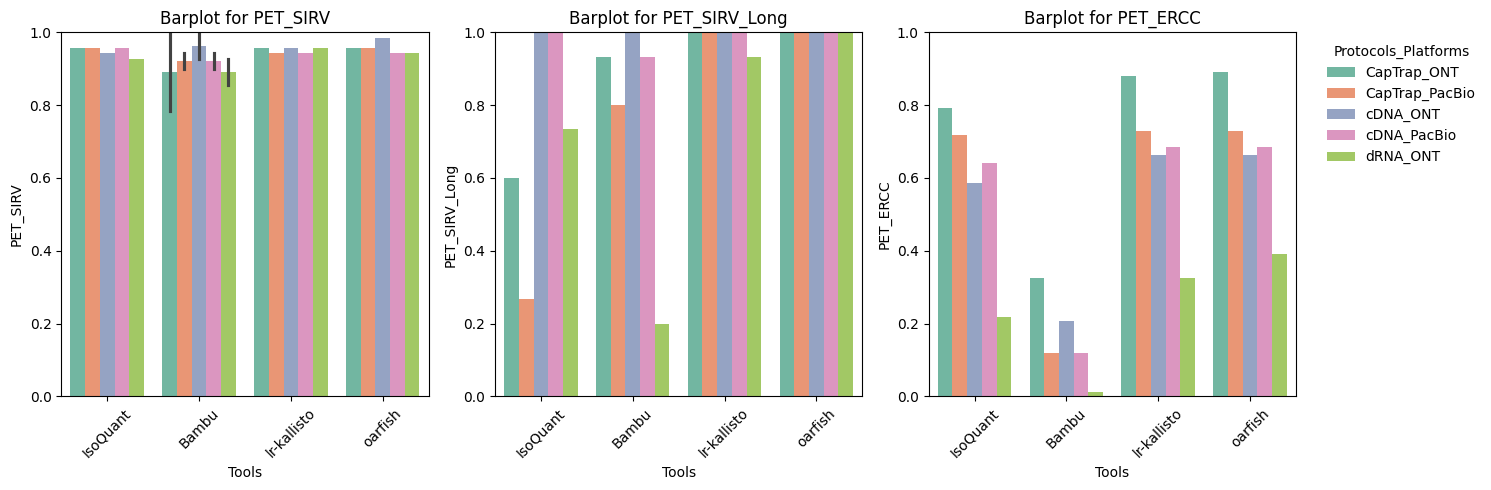

In [194]:
#!pip install pandas seaborn matplotlib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Function to generate box and whisker plots
def generate_boxplots(input_file):
    # Read the TSV file into a pandas DataFrame
    df = pd.read_csv(input_file, sep='\t')

    # Set up the matplotlib figure
    plt.figure(figsize=(15, 5))

    # Generate separate boxplots for MRD, SCC, and NRMSE
    columns_to_plot = ['PET_SIRV', 'PET_SIRV_Long', 'PET_ERCC']
    for i, col in enumerate(columns_to_plot):
        plt.subplot(1, 3, i+1)  # Create 1 row and 3 columns of plots
        
        # Create a boxplot with 'Tools' on x-axis and 'Protocols_Platforms' for coloring
        sns.barplot(x='Tools', y=col, data=df, hue='Protocols_Platforms', palette="Set2")

        # Set plot title and labels
        plt.title(f'Barplot for {col}')
        plt.xlabel('Tools')
        plt.ylabel(col)
        plt.ylim(0, round(np.max(df[col])))
        plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
        plt.legend([], [], frameon=False)

    plt.legend(title='Protocols_Platforms', loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

    # Adjust layout to make sure labels fit
    plt.tight_layout()

    # Show the plot
    plt.show()

# Example usage
input_file = 'Challenge2_Figures_Data/SIRV-set4_data/lr_kallisto_PET_metrics.txt'  # Replace with the path to your TSV file
generate_boxplots(input_file)


In [ ]:
# Import necessary libraries
import pandas as pd
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord 
import random 

# Define function to read in transcriptome fasta file
def read_transcriptome(fasta_file):
    transcripts = {}
    for record in SeqIO.parse(fasta_file, "fasta"):
        if "SIRV" in record.id:
            transcripts[record.id] = record.seq
    return transcripts

# Function to write long read to fastq file
def write_read(fused_transcript, output_file, gene_id, letter_annot):
    with open(output_file, "a") as f:
        record = SeqRecord(Seq(fused_transcript), id=gene_id, letter_annotations={"phred_quality": [ord(char) - 33 for char in letter_annot]})
        SeqIO.write(record, f, "fastq")

# Main script 
if __name__ == "__main__":
    # Load transcriptome data 
    transcriptome_file = "LRGASP.human.cdna.fasta"
    transcripts = read_transcriptome(transcriptome_file)

    '''
    for i in range(0,1000000):
        # Select two random genes to fuse 
        gene_a = random.choice(list(transcripts.keys()))
        breakpoint_a = 0 
        # Generate random breakpoint positions within full length transcript to create truncation
        #not used for perfect case
        if 500 > len(transcripts[gene_a])-300:
            continue
        else:
            start = 500
            breakpoint_a = random.randint(start, len(transcripts[gene_a]) - 100)

        # Write the full length transcript to a new fastq file
        letter_annotations = "I" * len(transcripts[gene_a])
        output_file = "SIRV_full_length_transcripts.fastq" 
        write_read(transcripts[gene_a], output_file, f"{gene_a}", letter_annotations) 
    '''
    transcript_keys = list(transcripts.keys())
    for i in range(0,len(transcript_keys)):
        gene_a = transcript_keys[i]
        for j in range(0, 1000):
            # Write the full length transcript to a new fastq file
            letter_annotations = "I" * len(transcripts[gene_a])
            output_file = "SIRV_full_length_transcripts_uniform.fastq" 
            write_read(transcripts[gene_a], output_file, f"{gene_a}", letter_annotations) 

In [195]:
#!python3 generate_sim_SIRV_perf.py 
!cat SIRV_full_length_transcripts.fastq | grep "@" | awk -F' ' '{print $1}' | awk -F'@' '{print $2}' | sort | uniq -c | awk '{print $1"\t"$2}' > SIRV_full_length_transcripts.count
!cat SIRV_full_length_transcripts_uniform.fastq | grep "@" | awk -F' ' '{print $1}' | awk -F'@' '{print $2}' | sort | uniq -c | awk '{print $1"\t"$2}' > SIRV_full_length_transcripts_uniform.count

In [ ]:
!kb count -k 63 -i lrgasp_sirv4_k-63.idx -g lrgasp_sirv4.t2g.txt --quant-umis --tcc -x bulk --long --platform PacBio --parity single --matrix-to-directories -o SIRV_full_length_transcripts_kb SIRV_full_length_transcripts.fastq 

[2025-04-12 22:36:53,413] WARNING [main] `--fragment-l` and `--fragment-s` not provided. Assuming all transcripts have the exact same length.
[2025-04-12 22:36:55,952]    INFO [count] Using index lrgasp_sirv4_k-63.idx to generate BUS file to SIRV_full_length_transcripts_kb from
[2025-04-12 22:36:55,952]    INFO [count]         SIRV_full_length_transcripts.fastq
[2025-04-12 22:37:28,295]    INFO [count] Sorting BUS file SIRV_full_length_transcripts_kb/output.bus to SIRV_full_length_transcripts_kb/tmp/output.s.bus


In [ ]:
!kb count -k 63 -i lrgasp_sirv4_k-63.idx -g lrgasp_sirv4.t2g.txt --quant-umis --tcc -x bulk --long --platform ONT --parity single --matrix-to-directories -o SIRV_full_length_transcripts_kb_ONT SIRV_full_length_transcripts.fastq 

In [ ]:
platform_PacBio = 'SIRV_full_length_transcripts_kb/quant_unfiltered/abundance_1/abundance.tsv'
platform_ONT = 'SIRV_full_length_transcripts_kb_ONT/quant_unfiltered/abundance_1/abundance.tsv'
GT = 'SIRV_full_length_transcripts.count'

import pandas as pd
from scipy.stats import spearmanr

def difference(platform):
    # Step 1: Read the data into pandas DataFrames
    df1 = pd.read_csv(platform, sep='\t', header=0)  # Replace 'file1.tsv' with the correct path
    df2 = pd.read_csv(GT, sep='\t', header=None, names=['counts', 'target_id'])  # Replace 'file2.tsv' with the correct path
    df1_df2 = df1.merge(df2, on='target_id', how='inner')
    
    # Step 2: Extract the necessary columns
    est_counts = df1_df2['est_counts']  # Replace with the actual column name if different
    first_column = df1_df2['counts']  # First column of the second DataFrame
    
    # Step 3: Calculate Spearman's rho
    rho, p_value = spearmanr(est_counts, first_column)
    
    # Print the result
    print(f"Spearman's rho: {rho}")
    print(f"P-value: {p_value}")
    df1_df2['diff'] = est_counts - first_column
    print(df1_df2)

difference(platform_PacBio)
difference(platform_ONT)

In [199]:
!kb count -k 63 -i lrgasp_sirv4_k-63.idx -g lrgasp_sirv4.t2g.txt --quant-umis --tcc -x bulk --long --platform PacBio --parity single --matrix-to-directories -o SIRV_full_length_transcripts_uniform_kb SIRV_full_length_transcripts_uniform.fastq 
!kb count -k 63 -i lrgasp_sirv4_k-63.idx -g lrgasp_sirv4.t2g.txt --quant-umis --tcc -x bulk --long --platform ONT --parity single --matrix-to-directories -o SIRV_full_length_transcripts_uniform_kb_ONT SIRV_full_length_transcripts_uniform.fastq 

[2025-04-09 13:48:39,286] WARNING [main] `--fragment-l` and `--fragment-s` not provided. Assuming all transcripts have the exact same length.
[2025-04-09 13:48:43,269]    INFO [count] Using index lrgasp_sirv4_k-63.idx to generate BUS file to SIRV_full_length_transcripts_uniform_kb_ONT from
[2025-04-09 13:48:43,269]    INFO [count]         SIRV_full_length_transcripts_uniform.fastq
[2025-04-09 13:48:46,474]    INFO [count] Sorting BUS file SIRV_full_length_transcripts_uniform_kb_ONT/output.bus to SIRV_full_length_transcripts_uniform_kb_ONT/tmp/output.s.bus
[2025-04-09 13:48:48,778]    INFO [count] Inspecting BUS file SIRV_full_length_transcripts_uniform_kb_ONT/tmp/output.s.bus
[2025-04-09 13:48:49,880]    INFO [count] Generating count matrix SIRV_full_length_transcripts_uniform_kb_ONT/counts_unfiltered/cells_x_tcc from BUS file SIRV_full_length_transcripts_uniform_kb_ONT/tmp/output.s.bus
[2025-04-09 13:48:51,067]    INFO [count] Quantifying transcript abundances to SIRV_full_length_tran

In [200]:
platform_PacBio = 'SIRV_full_length_transcripts_uniform_kb/quant_unfiltered/abundance_1/abundance.tsv'
platform_ONT = 'SIRV_full_length_transcripts_uniform_kb_ONT/quant_unfiltered/abundance_1/abundance.tsv'
GT = 'SIRV_full_length_transcripts_uniform.count'

import pandas as pd
from scipy.stats import spearmanr

def difference(platform):
    # Step 1: Read the data into pandas DataFrames
    df1 = pd.read_csv(platform_PacBio, sep='\t', header=0)  # Replace 'file1.tsv' with the correct path
    df2 = pd.read_csv(GT, sep='\t', header=None, names=['counts', 'target_id'])  # Replace 'file2.tsv' with the correct path
    df1_df2 = df1.merge(df2, on='target_id', how='inner')
    
    # Step 2: Extract the necessary columns
    est_counts = df1_df2['est_counts']  # Replace with the actual column name if different
    first_column = df1_df2['counts']  # First column of the second DataFrame
    
    # Step 3: Calculate Spearman's rho
    rho, p_value = spearmanr(est_counts, first_column)
    
    # Print the result
    #print(f"Spearman's rho: {rho}")
    #print(f"P-value: {p_value}")
    df1_df2['diff'] = est_counts - first_column
    print(df1_df2)
    print(df1_df2[df1_df2['diff']> 0])
    print(df1_df2[df1_df2['diff']< 0])

difference(platform_PacBio)
difference(platform_ONT)

    target_id  length  eff_length  est_counts      tpm  counts  diff
0     SIRV101    1561           1      1000.0  11904.8    1000   0.0
1     SIRV102    1300           1      1000.0  11904.8    1000   0.0
2     SIRV103    1363           1      1000.0  11904.8    1000   0.0
3     SIRV105     670           1      1000.0  11904.8    1000   0.0
4     SIRV106     973           1      1000.0  11904.8    1000   0.0
..        ...     ...         ...         ...      ...     ...   ...
79  SIRV10002   10001           1      1000.0  11904.8    1000   0.0
80  SIRV10003    9970           1      1000.0  11904.8    1000   0.0
81  SIRV12001   12029           1      1000.0  11904.8    1000   0.0
82  SIRV12002   11999           1      1000.0  11904.8    1000   0.0
83  SIRV12003   12000           1      1000.0  11904.8    1000   0.0

[84 rows x 7 columns]
   target_id  length  eff_length  est_counts      tpm  counts     diff
8    SIRV201    2051           1     1333.33  15873.0    1000   333.33
9    SI

In [201]:
!cat lrgasp_sirv4.cdna.fa | grep -v "SIRV101" | grep -v "SIRV201" | grep -v "SIRV304" > lrgasp_sirv4_m_101_201_304.cdna.fa
!head lrgasp_sirv4_m_101_201_304.cdna.fa 
!cat lrgasp_sirv4.t2g.txt | grep -v "SIRV101" | grep -v "SIRV201" | grep -v "SIRV304" > lrgasp_sirv4_m_101_201_304.t2g.txt
!head lrgasp_sirv4_m_101_201_304.t2g.txt

>DQ459430 gene_id:ERCC-00002A gene_name: transcript_name: chr:ERCC-00002 start:1 end:1045 strand:+
GGGAATTCTCCAGATTACTTCCATTTCCGCCCAAGCTGCTCACAGTATACGGGCGTCGGCATCCAGACCGTCGGCTGATCGTGGTTTTACTAGGCTAGACTAGCGTACGAGCACTATGGTCAGTAATTCCTGGAGGAATAGGTACCAAGAAAAAAACGAACCTTTGGGTTCCAGAGCTGTACGGTCGCACTGAACTCGGATAGGTCTCAGAAAAACGAAATATAGGCTTACGGTAGGTCCGAATGGCACAAAGCTTGTTCCGTTAGCTGGCATAAGATTCCATGCCTAGATGTGATACACGTTTCTGGAAACTGCCTCGTCATGCGACTGTTCCCCGGGGTCAGGGCCGCTGGTATTTGCTGTAAAGAGGGGCGTTGAGTCCGTCCGACTTCACTGCCCCCTTTCAGCCTTTTGGGTCCTGTATCCCAATTCTCAGAGGTCCCGCCGTACGCTGAGGACCACCTGAAACGGGCATCGTCGCTCTTCGTTGTTCGTCGACTTCTAGTGTGGAGACGAATTGCCAGAATTATTAACTGCGCAGTTAGGGCAGCGTCTGAGGAAGTTTGCTGCGGTTTCGCCTTGACCGCGGGAAGGAGACATAACGATAGCGACTCTGTCTCAGGGGATCTGCATATGTTTGCAGCATACTTTAGGTGGGCCTTGGCTTCCTTCCGCAGTCAAAACCGCGCAATTATCCCCGTCCTGATTTACTGGACTCGCAACGTGGGTCCATCAGTTGTCCGTATACCAAGACGTCTAAGGGCGGTGTACACCCTTTTGAGCAATGATTGCACAACCTGCGATCACCTTATACAGAATTATCAATCAAGCTCCCCGAGGAGCGGACTTGTAAGGACCGCCGCTTTCGCTCGGGTCTGCGGGTTATAGCTTTTCAGTCTCG

In [209]:
!kallisto_v0.51.1/kallisto/build/src/kallisto index -k 63 -i lrgasp_sirv4_m_101_201_304.idx lrgasp_sirv4_m_101_201_304.cdna.fa
!kallisto_v0.51.1/kallisto/build/src/kallisto index -k 31 -i lrgasp_sirv4_m_101_201_304.31.idx lrgasp_sirv4_m_101_201_304.cdna.fa


[build] loading fasta file lrgasp_sirv4_m_101_201_304.cdna.fa
[build] k-mer length: 63
KmerStream::KmerStream(): Start computing k-mer cardinality estimations (1/2)
KmerStream::KmerStream(): Start computing k-mer cardinality estimations (1/2)
KmerStream::KmerStream(): Finished
CompactedDBG::build(): Estimated number of k-mers occurring at least once: 222895
CompactedDBG::build(): Estimated number of minimizer occurring at least once: 55058
CompactedDBG::filter(): Processed 266791 k-mers in 173 reads
CompactedDBG::filter(): Found 221937 unique k-mers
CompactedDBG::filter(): Number of blocks in Bloom filter is 1525
CompactedDBG::construct(): Extract approximate unitigs (1/2)
CompactedDBG::construct(): Extract approximate unitigs (2/2)
CompactedDBG::construct(): Closed all input files

CompactedDBG::construct(): Splitting unitigs (1/2)

CompactedDBG::construct(): Splitting unitigs (2/2)
CompactedDBG::construct(): Before split: 381 unitigs
CompactedDBG::construct(): After split (1/1): 381

In [203]:
!kb count -k 63 -i lrgasp_sirv4_m_101_201_304.idx -g lrgasp_sirv4_m_101_201_304.t2g.txt --quant-umis --tcc -x bulk --long --threshold .01 --platform PacBio --parity single --matrix-to-directories -o SIRV_full_length_transcripts_uniform_kb_minus SIRV_full_length_transcripts_uniform.fastq 
!kb count -k 63 -i lrgasp_sirv4_m_101_201_304.idx -g lrgasp_sirv4_m_101_201_304.t2g.txt --quant-umis --tcc -x bulk --long --threshold .01 --platform ONT --parity single --matrix-to-directories -o SIRV_full_length_transcripts_uniform_kb_ONT_minus SIRV_full_length_transcripts_uniform.fastq 

[2025-04-09 13:48:58,803] WARNING [main] `--fragment-l` and `--fragment-s` not provided. Assuming all transcripts have the exact same length.
[2025-04-09 13:49:02,895]    INFO [count] Skipping kallisto bus because output files already exist. Use the --overwrite flag to overwrite.
[2025-04-09 13:49:02,895]    INFO [count] Sorting BUS file SIRV_full_length_transcripts_uniform_kb_minus/output.bus to SIRV_full_length_transcripts_uniform_kb_minus/tmp/output.s.bus
[2025-04-09 13:49:05,300]    INFO [count] Inspecting BUS file SIRV_full_length_transcripts_uniform_kb_minus/tmp/output.s.bus
[2025-04-09 13:49:06,402]    INFO [count] Generating count matrix SIRV_full_length_transcripts_uniform_kb_minus/counts_unfiltered/cells_x_tcc from BUS file SIRV_full_length_transcripts_uniform_kb_minus/tmp/output.s.bus
[2025-04-09 13:49:07,544]    INFO [count] Quantifying transcript abundances to SIRV_full_length_transcripts_uniform_kb_minus/quant_unfiltered from mtx file SIRV_full_length_transcripts_uniform_

In [204]:
platform_PacBio = 'SIRV_full_length_transcripts_uniform_kb_minus/quant_unfiltered/abundance_1/abundance.tsv'
platform_ONT = 'SIRV_full_length_transcripts_uniform_kb_ONT_minus/quant_unfiltered/abundance_1/abundance.tsv'
GT = 'SIRV_full_length_transcripts_uniform.count'

import pandas as pd
from scipy.stats import spearmanr

def difference(platform):
    # Step 1: Read the data into pandas DataFrames
    df1 = pd.read_csv(platform_PacBio, sep='\t', header=0)  # Replace 'file1.tsv' with the correct path
    df2 = pd.read_csv(GT, sep='\t', header=None, names=['counts', 'target_id'])  # Replace 'file2.tsv' with the correct path
    df1_df2 = df1.merge(df2, on='target_id', how='outer')
    df1_df2.fillna(0)
    
    # Step 2: Extract the necessary columns
    est_counts = df1_df2['est_counts']  # Replace with the actual column name if different
    first_column = df1_df2['counts']  # First column of the second DataFrame
    
    # Step 3: Calculate Spearman's rho
    rho, p_value = spearmanr(est_counts, first_column)
    
    # Print the result
    #print(f"Spearman's rho: {rho}")
    #print(f"P-value: {p_value}")
    df1_df2['diff'] = est_counts - first_column
    print(df1_df2)
    print(df1_df2[df1_df2['diff']> 0])
    print(df1_df2[df1_df2['diff']< 0])

difference(platform_PacBio)
difference(platform_ONT)

    target_id  length  eff_length  est_counts      tpm  counts  diff
0    DQ459412  1120.0         1.0         0.0      0.0     NaN   NaN
1    DQ459413  1114.0         1.0         0.0      0.0     NaN   NaN
2    DQ459415  1126.0         1.0         0.0      0.0     NaN   NaN
3    DQ459418  1120.0         1.0         0.0      0.0     NaN   NaN
4    DQ459419  1120.0         1.0         0.0      0.0     NaN   NaN
..        ...     ...         ...         ...      ...     ...   ...
171   SIRV706   949.0         1.0      1000.0  11904.8  1000.0   0.0
172   SIRV708   889.0         1.0      1000.0  11904.8  1000.0   0.0
173  SIRV8001  8001.0         1.0      1000.0  11904.8  1000.0   0.0
174  SIRV8002  8000.0         1.0      1000.0  11904.8  1000.0   0.0
175  SIRV8003  8000.0         1.0      1000.0  11904.8  1000.0   0.0

[176 rows x 7 columns]
    target_id  length  eff_length  est_counts      tpm  counts     diff
102   SIRV109  2515.0         1.0     2333.33  27777.8  1000.0  1333.33
107 

In [210]:
!/home/rloving/kallisto_v0.51.1/kallisto/build/src/kallisto bus -x bulk -i lrgasp_sirv4_m_101_201_304.31.idx -x bulk --long --threshold 0.000000001 -o SIRV_full_length_transcripts_uniform_kb_minus SIRV_full_length_transcripts_uniform.fastq


[index] k-mer length: 31
[index] number of targets: 173
[index] number of k-mers: 224,092
Using supplied threshold 1e-09
[quant] running in long read mode
[quant] will process file 1: SIRV_full_length_transcripts_uniform.fastq
proc = 0finding pseudoalignments for all files ...
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
proc = 0
p